In [1]:
import pandas as pd

DATA_FILE = "../data/processed/ontario_demand_2025_clean.csv"

df = pd.read_csv(DATA_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,date,hour,market_demand,ontario_demand
0,2025-01-01 00:00:00,2025-01-01,1,17247,13887
1,2025-01-01 01:00:00,2025-01-01,2,17355,13722
2,2025-01-01 02:00:00,2025-01-01,3,17638,13688
3,2025-01-01 03:00:00,2025-01-01,4,17065,13613
4,2025-01-01 04:00:00,2025-01-01,5,17498,13593


In [2]:
X = df[["hour"]]
y = df["ontario_demand"]

In [4]:
X.head()

,hour
0,1
1,2
2,3
3,4
4,5


In [5]:
y.head()

0    13887
1    13722
2    13688
3    13613
4    13593
Name: ontario_demand, dtype: int64

In [7]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

print("\nTraining period:")
print(df.iloc[0]["timestamp"], "to", df.iloc[split_index - 1]["timestamp"])

print("\nTesting period:")
print(df.iloc[split_index]["timestamp"], "to", df.iloc[-1]["timestamp"])

Training examples: 7007
Testing examples: 1752

Training period:
2025-01-01 00:00:00 to 2025-10-19 23:00:00

Testing period:
2025-10-20 00:00:00 to 2025-12-31 23:00:00


## Train the Baseline Model

This linear regression model will be trained using `hour` as the only feature.
The model learns an equation of the form: ŷ = w * hour + b

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[151.25]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['hour']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.462e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [11]:
weight = model.coef_[0]
bias = model.intercept_

print("Weight:", weight)
print("Bias:", bias)

Weight: 151.24881120165122
Bias: 14619.159752753898


In [12]:
y_pred = model.predict(X_test)

In [13]:
y_pred[:10]

array([14770.40856396, 14921.65737516, 15072.90618636, 15224.15499756,
       15375.40380876, 15526.65261996, 15677.90143117, 15829.15024237,
       15980.39905357, 16131.64786477])

In [14]:
comparison = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted": y_pred[:10]
})

comparison

,actual,predicted
0,12527,14770.408564
1,12302,14921.657375
2,12328,15072.906186
3,12461,15224.154998
4,12956,15375.403809
5,14184,15526.652620
6,15566,15677.901431
7,16167,15829.150242
8,16191,15980.399054
9,15978,16131.647865


## Evaluating the Baseline Model

The model will be evaluated using Mean Squared Error (MSE). Lower MSE indicates better predictions.

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 2972982.9014425385
RMSE: 1724.234004258859


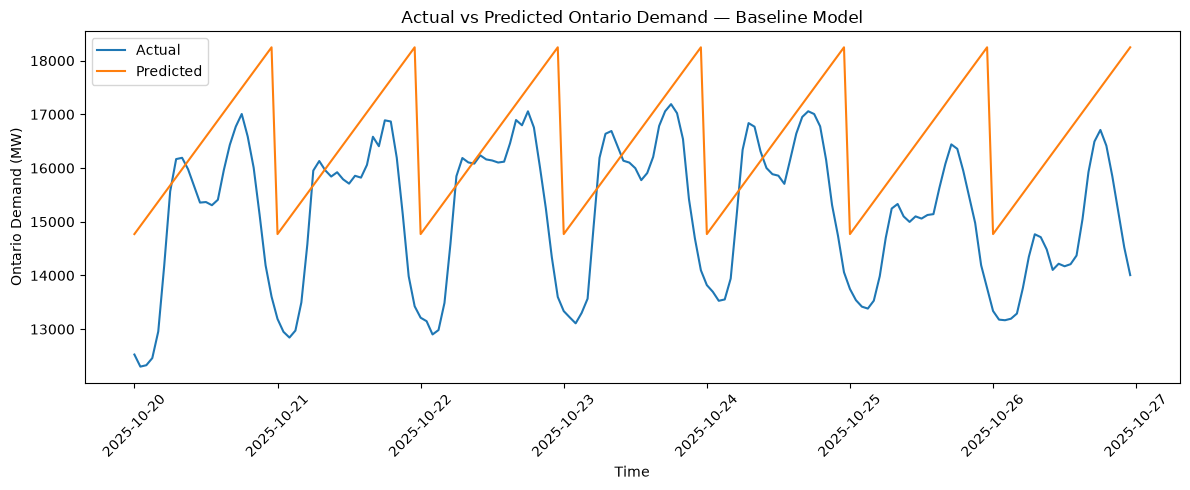

In [18]:
import matplotlib.pyplot as plt

plot_size = 24 * 7
timestamps = df.iloc[split_index:split_index + plot_size]["timestamp"]
plt.figure(figsize=(12, 5))
plt.plot(
    timestamps,
    y_test.iloc[:plot_size],
    label="Actual"
)

plt.plot(
    timestamps,
    y_pred[:plot_size],
    label="Predicted"
)

plt.title("Actual vs Predicted Ontario Demand — Baseline Model")
plt.xlabel("Time")
plt.ylabel("Ontario Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()